In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'

# Configuration
em_resolution = 's1' # 8x8x8 nm voxels
segmentation_resolution = 's0' # 8x8x8 nm voxels

data_manager = DataManager(group_url, seg_url, em_resolution, segmentation_resolution, 'jrc_mus-liver')


/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))
/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [4]:
data_manager.em_data.view_groups()

(
    ('s0', <zarr.core.Array '/em/fibsem-uint8/s0' (8932, 12728, 12747) uint8 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint8/s1' (4466, 6364, 6373) uint8 read-only>),
    ('s10', <zarr.core.Array '/em/fibsem-uint8/s10' (8, 12, 12) uint8 read-only>),
    ('s11', <zarr.core.Array '/em/fibsem-uint8/s11' (4, 6, 6) uint8 read-only>),
    ('s12', <zarr.core.Array '/em/fibsem-uint8/s12' (2, 3, 3) uint8 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint8/s2' (2233, 3182, 3186) uint8 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint8/s3' (1116, 1591, 1593) uint8 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint8/s4' (558, 795, 796) uint8 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint8/s5' (279, 397, 398) uint8 read-only>),
    ('s6', <zarr.core.Array '/em/fibsem-uint8/s6' (139, 198, 199) uint8 read-only>),
    ('s7', <zarr.core.Array '/em/fibsem-uint8/s7' (69, 99, 99) uint8 read-only>),
    ('s8', <zarr.core.Array '/em/fibsem-uint8/s8' (34, 49, 49) uint8 read-only>),
    ('s9', <zarr.core.Array '/em/fibsem-uint8/s9' (17, 24, 24) uint8 read-only>)
)

In [5]:
data_manager.segmentation_data.view_groups()

(
    ('s0', <zarr.core.Array '/labels/mito_seg/s0' (4466, 6364, 6372) uint32 read-only>),
    ('s1', <zarr.core.Array '/labels/mito_seg/s1' (2233, 3182, 3186) uint32 read-only>),
    ('s2', <zarr.core.Array '/labels/mito_seg/s2' (1116, 1591, 1593) uint32 read-only>),
    ('s3', <zarr.core.Array '/labels/mito_seg/s3' (558, 795, 796) uint32 read-only>),
    ('s4', <zarr.core.Array '/labels/mito_seg/s4' (279, 397, 398) uint32 read-only>),
    ('s5', <zarr.core.Array '/labels/mito_seg/s5' (139, 198, 199) uint32 read-only>),
    ('s6', <zarr.core.Array '/labels/mito_seg/s6' (69, 99, 99) uint32 read-only>)
)

In [6]:
from src.slice_generator import SliceGenerator

# 16 nm per px, 128 px patch sizes capture ~31-62 px mitochondria (see readme.md)
patch_size = 512

# Z-step, 128 px (2 microns) per plane
z_step = 128

# Inset to handle microscopy edge effects from the slices
inset = 128

slicer = SliceGenerator(data_manager, patch_size, z_step, inset)
slices = slicer.generate()

In [10]:
from src.model import load_vitb16_model, load_vits16_model, load_vith16plus_model

vits_model = load_vits16_model() # smallest
# vitb_model = load_vitb16_model() # baseline, medium
# vithplus_model = load_vith16plus_model() # largest model

model = vits_model


In [11]:
from src.embeddings import EmbeddingsManager

embeddings_manager = EmbeddingsManager(data_manager, model)

In [12]:
import numpy as np

# Select 200 random slices to examine for mitochondria
num_slices_search = 10
np.random.seed(123)
slice_indices = np.random.choice(len(slices), size=num_slices_search)
slices_subset = [slices[i] for i in slice_indices]

In [253]:
from src.mito_slice_manager import MitoSliceManager

# Build catalog of mitochondria to slices (filtering out
# slices without mitochondria)
mito_slice_manager = MitoSliceManager(data_manager, slices_subset)
mito_catalog = mito_slice_manager.build()
mito_ids = mito_slice_manager.mito_ids()
slices_with_mito = mito_slice_manager.best_slices()


0/10 - 00:00:00.519
9/10 - 00:00:04.259


In [178]:
print(f"Of the {len(slices)} total slices, ")
print(f"   we examine {len(slices_with_mito)} ({len(slices_with_mito)/len(slices)*100:.1f}%) with {len(mito_ids)} mitochondria")

Of the 19008 total slices, 
   we examine 9 (0.0%) with 94 mitochondria


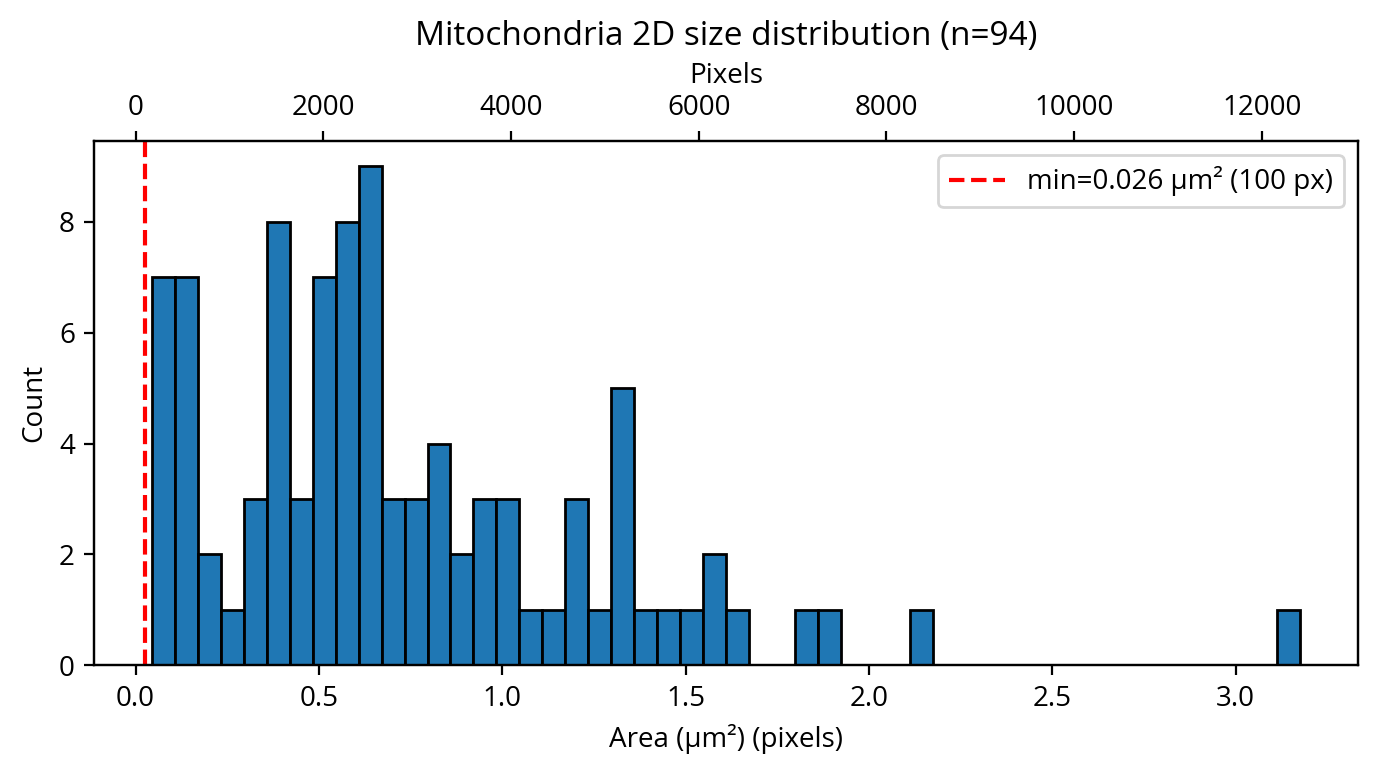

In [179]:
mito_slice_manager.plot_size_distribution()

In [180]:
all_patch_embeddings = embeddings_manager.compute_patch_embeddings(slices_subset)

0/10 - 00:00:01.637


In [181]:
mito_entry

MitoEntry(id=61998, slice_index=3, num_pixels=535, bbox=(0, 11, 0, 139))

In [182]:
mito_id = mito_ids[1]
mito_entry = mito_catalog[mito_id]
slice_index = mito_entry.slice_index

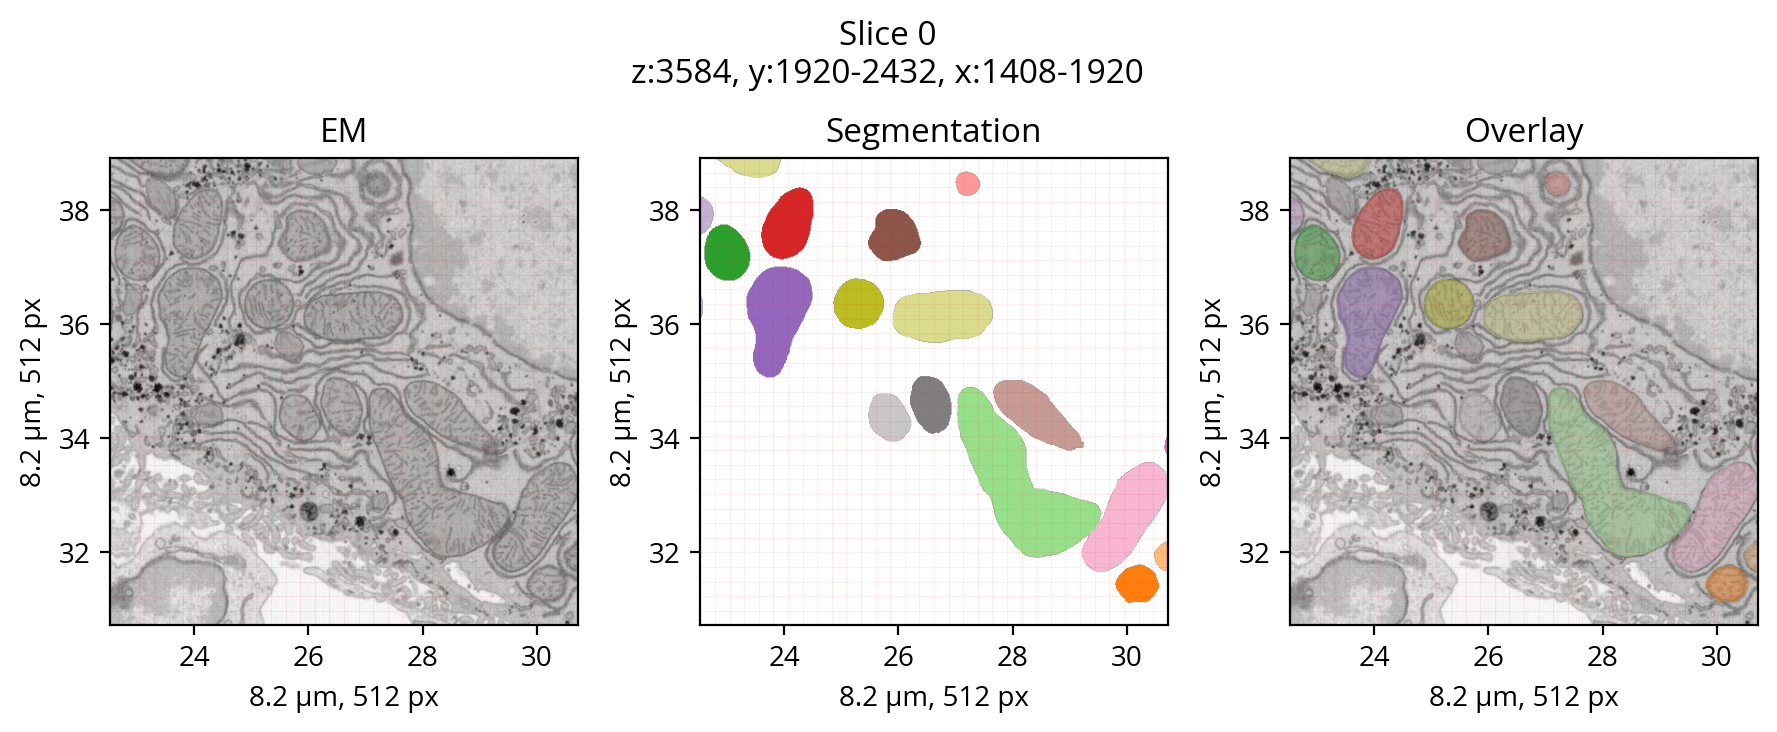

In [183]:
from src.visualizer import Visualizer
vis = Visualizer(data_manager)

slc = slices_subset[slice_index]

z_index_to_plot = slc.z.start
vis.plot_segmentation_example(slc, z_index=z_index_to_plot, title=f"Slice {slice_index}\n"
    f"z:{slc.z.start}, y:{slc.y.start}-{slc.y.stop}, x:{slc.x.start}-{slc.x.stop}")


In [184]:
from src.timer import Timer

# Compute the per-mitochondria embeddings
timer = Timer()
all_mito_vectors = {}
last_slice_index = None

for i, mito_id in enumerate(mito_ids):
    
    mito_entry = mito_catalog[mito_id]

    # Avoid duplicating repeated work (re-computing embeddings
    # for a slice with multiple mitochondrion
    if slice_index != mito_entry.slice_index:

        # Retrieve the slice and compute the patch embeddings
        slc = slices_subset[mito_entry.slice_index]

        # Compute at the patch level
        patch_embeddings = all_patch_embeddings[mito_entry.slice_index]
        slice_analyzer.set_slice(slc)

        # Set embeddings for the slice, analyzer will upscale to dense
        # using bilinear interpolation for 1:1 ratio with segmentation mask
        slice_analyzer.set_embeddings(patch_embeddings, is_dense=False)

    # Select the mitochondrion within the slice
    # and compute the reference vector as an average of the 
    slice_analyzer.select_mitochondrion(mito_id)
    all_mito_vectors[mito_id] = slice_analyzer.reference_vector

    if i % 10 == 0:
        timer.print_time(f"{i}/{len(mito_ids)}")


0/94 - 00:00:00.247
10/94 - 00:00:01.329
20/94 - 00:00:16.543
30/94 - 00:00:31.486
40/94 - 00:00:47.739
50/94 - 00:01:04.174
60/94 - 00:01:19.840
70/94 - 00:01:35.562
80/94 - 00:01:51.622
90/94 - 00:02:07.334


In [185]:
from src.slice_analyzer import SliceAnalyzer

# Test an analysis on a single mitochondrion within a slice
patch_embeddings = embeddings_manager.compute_patch_embedding(slc)
slice_analyzer = SliceAnalyzer(data_manager)

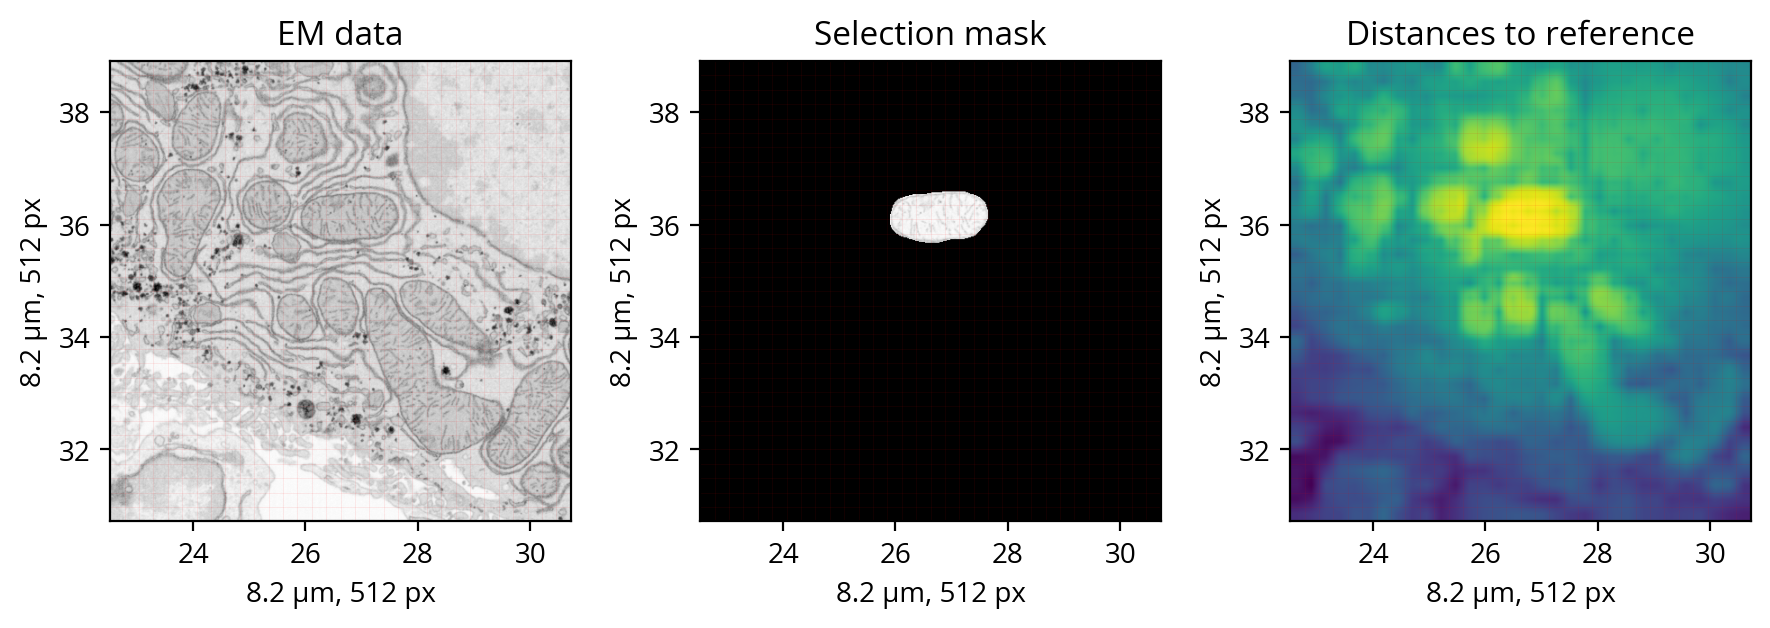

In [225]:
# What does distances look like for a reference mitochondrion?

# Select a mitochondrian and compute its embeddings, m
# Plot the distance from m to every other pixel embedding in the image
# Demonstrate that mitochondria semantic embeddings are captured.
mito_id = mito_ids[7]
mito_entry = mito_catalog[mito_id]
slc = slices_subset[mito_entry.slice_index]
patch_embeddings = all_patch_embeddings[mito_entry.slice_index]
slice_analyzer.set_slice(slc)
slice_analyzer.set_embeddings(patch_embeddings, is_dense=False)
        
_ = slice_analyzer.select_mitochondrion(mito_id)
_ = slice_analyzer.compute_distance_map()
slice_analyzer.plot()

In [240]:
# Compute mitochondrial distances to the reference mitochondrion
# in embedding space
from scipy.spatial.distance import cosine
mito_distances_to_reference = {}
for mito_id in mito_ids:
    target = all_mito_vectors[mito_id]
    dist_to_ref = cosine(reference_vector, target)
    mito_distances_to_reference[mito_id] = dist_to_ref


Text(0.5, 0, 'Cosine distance')

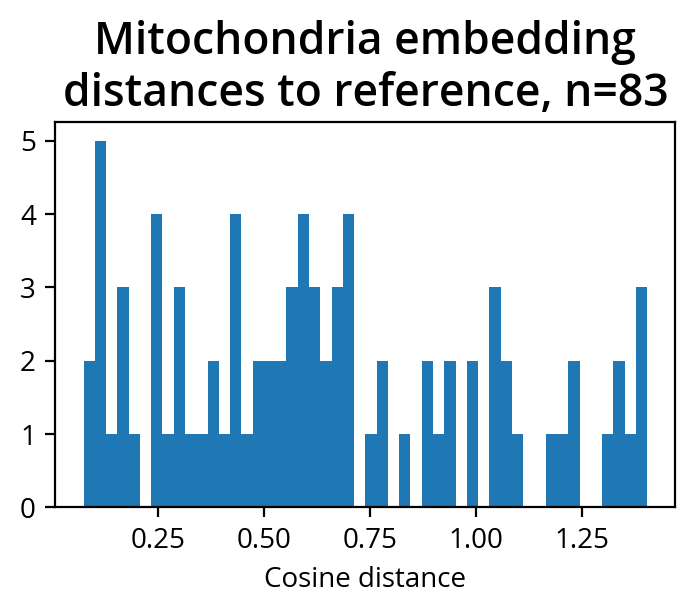

In [251]:
# Retrieve and plot representative examples
import pandas as pd

dists_to_ref_df = pd.DataFrame(mito_distances_to_reference.items(), columns=['mito_id', 'cosine_distance'])\
        .set_index('mito_id').sort_values('cosine_distance').dropna()

# Plot the distribution of distances to the reference
plt.figure(figsize=(4, 2.5))
plt.hist(dists_to_ref_df.cosine_distance, bins=50)
plt.title(f"Mitochondria embedding\ndistances to reference, n={len(dists_to_ref_df)}", fontsize=16, fontweight='demi')
plt.xlabel("Cosine distance")

In [249]:
dists_to_ref_df.head()

,cosine_distance
mito_id,
27500,0.074985
42348,0.081323
86102,0.110476
27497,0.111307
8853,0.111761


In [244]:
dists_to_ref_df.tail()

,cosine_distance
mito_id,
84124,1.336002
56515,1.355521
3017,1.399742
53508,1.403170
36888,1.403365


In [254]:
# Let's examine the closest and furthest examples

close_id = dists_to_ref_df.iloc[1].name
close_entry = mito_catalog[close_id]

far_id = dists_to_ref_df.dropna().iloc[-1].name
far_entry = mito_catalog[far_id]

In [256]:
far_entry.to_slice()

Slice at (z:slice(128, 128, None), y:slice(1208, 1236, None), x:slice(235, 268, None))

In [266]:
def plot_representative_example(mito_id):
    
    entry = mito_catalog[mito_id]
    
    from src.math_helpers import pad_slice_to_size
    slc = entry.to_slice()
    slc = pad_slice_to_size(slc, 114, 114)
    
    z_index_to_plot = slc.z.start
    vis.plot_segmentation_example(slc, z_index=z_index_to_plot, highlight_mito_id=mito_id)


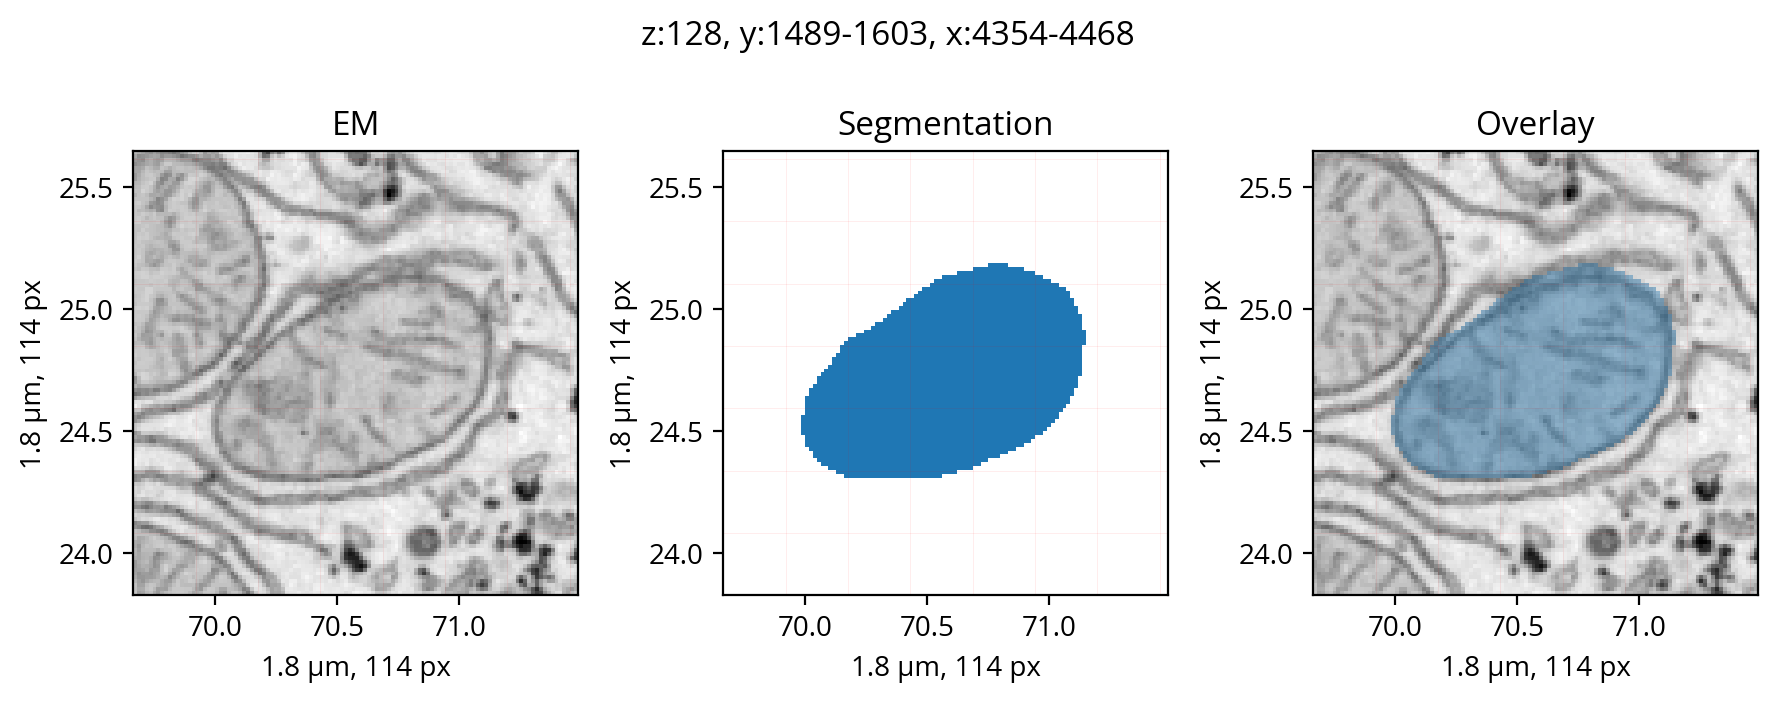

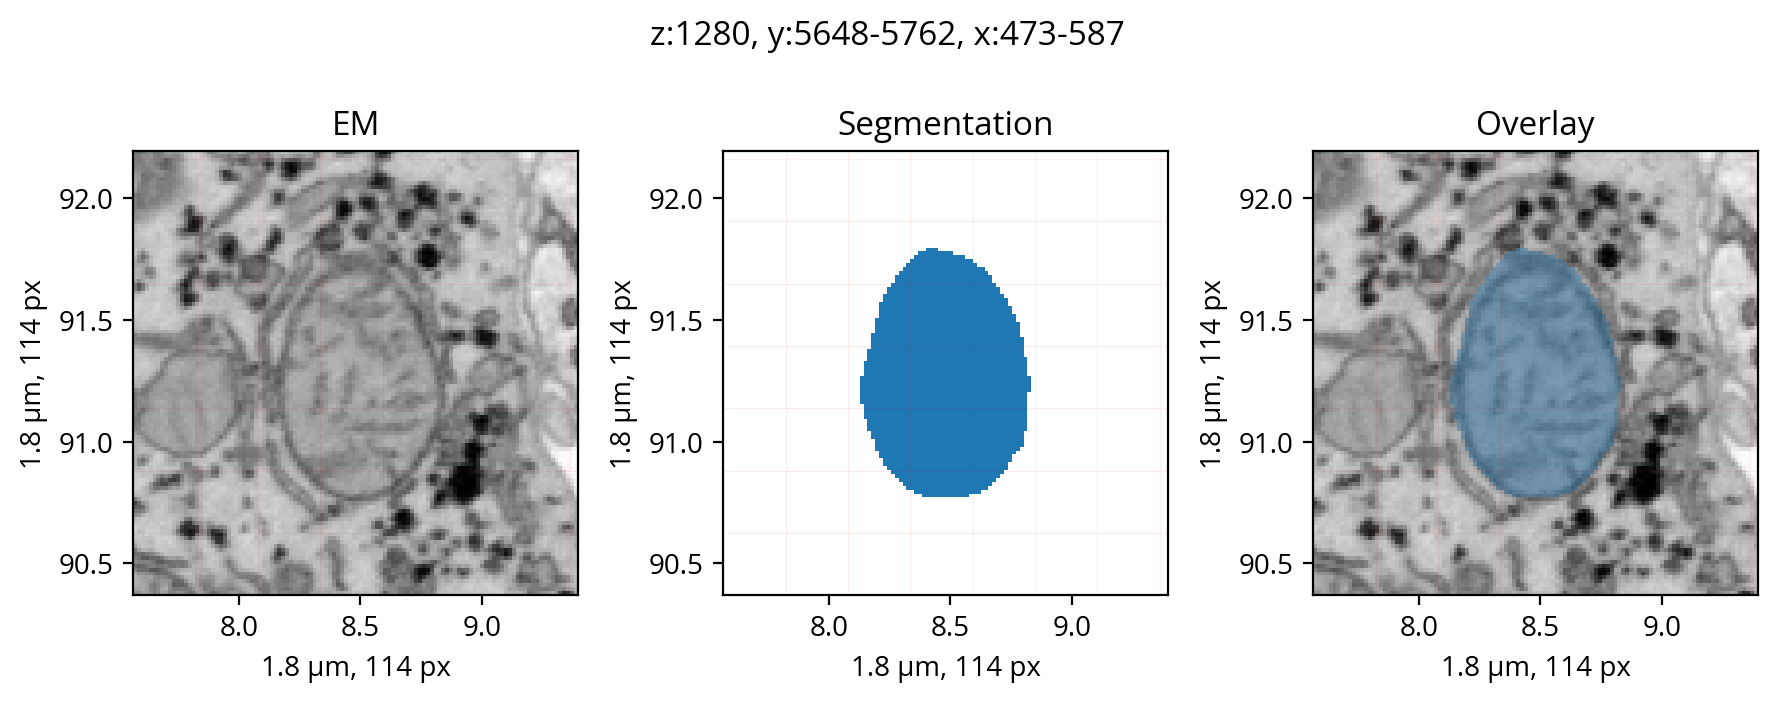

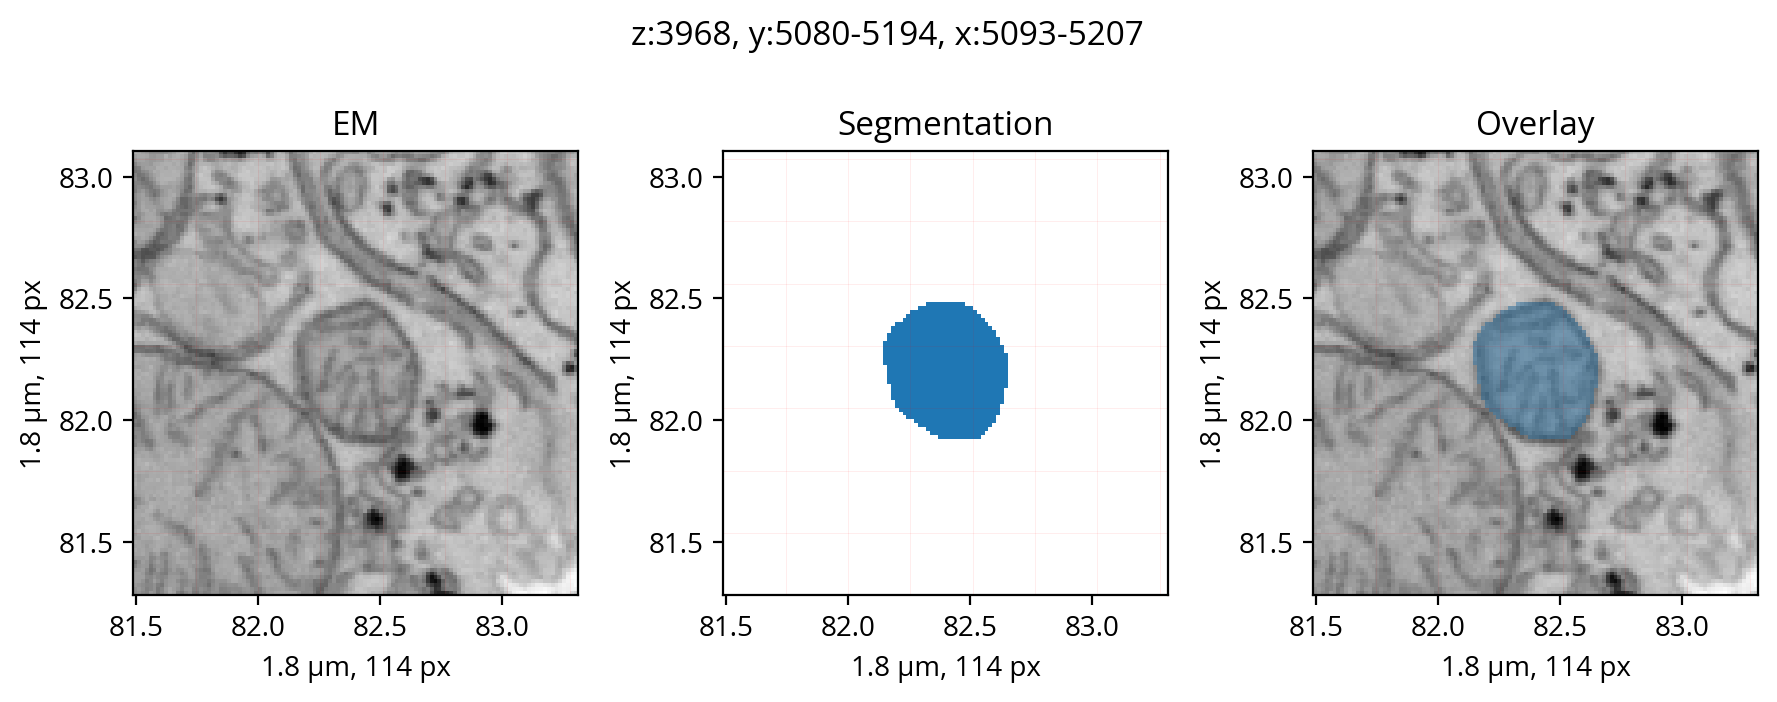

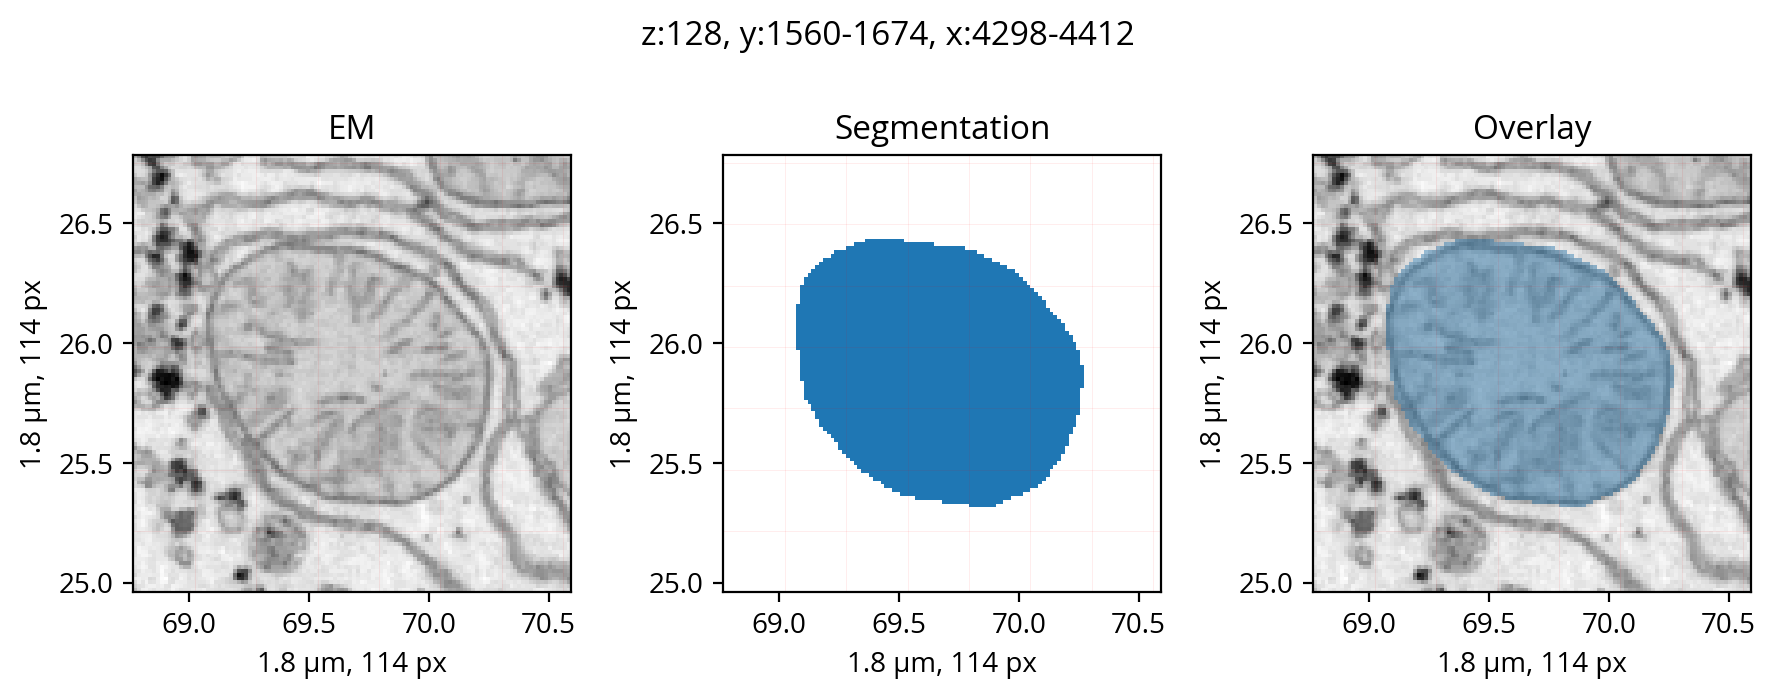

ValueError: Slice width 139 exceeds target 114

In [271]:
for close_id, _ in dists_to_ref_df.head(5).iterrows():
    plot_representative_example(close_id)

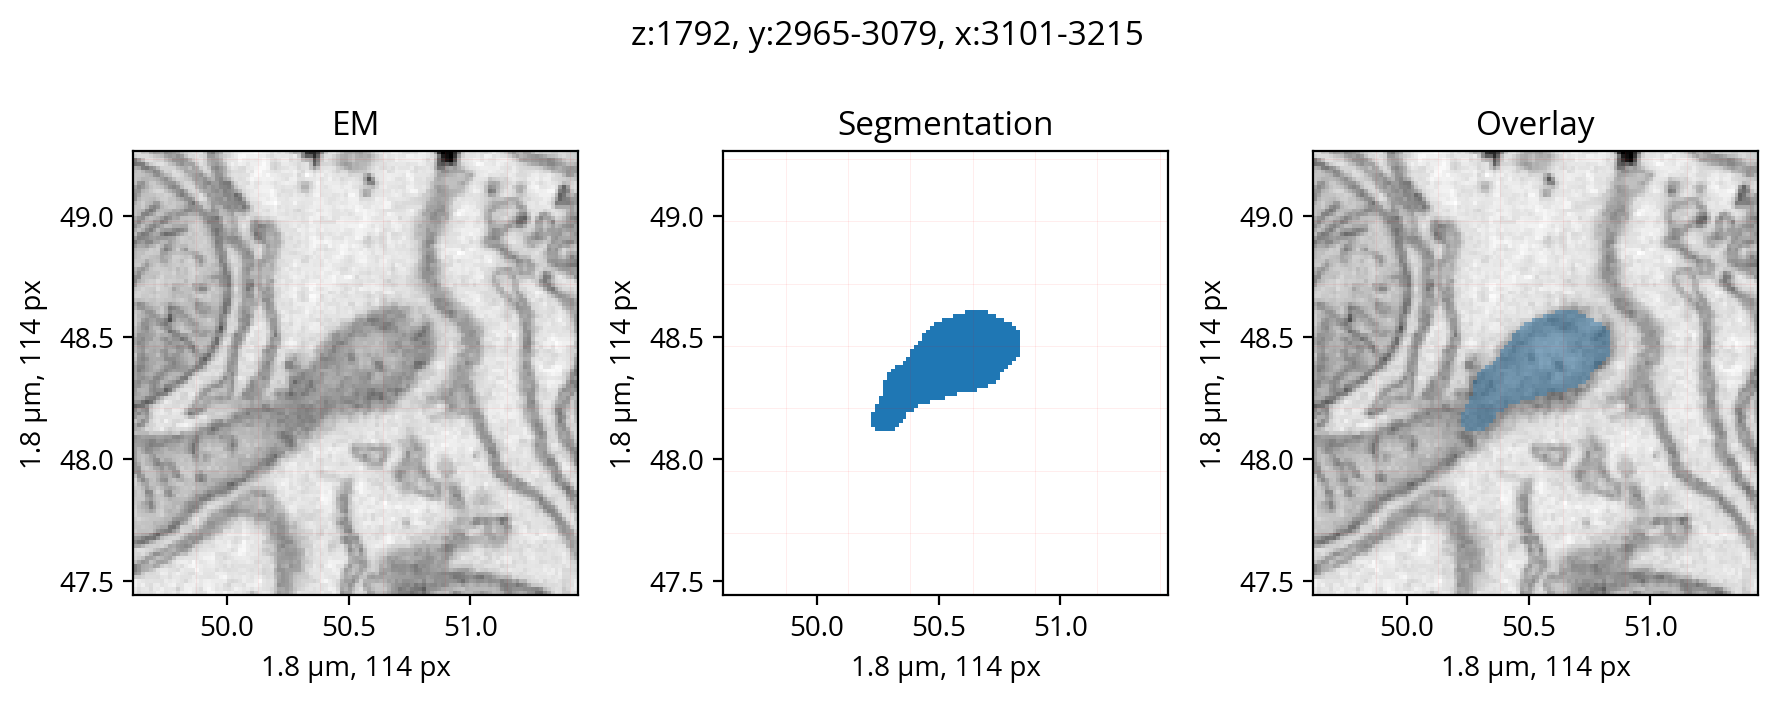

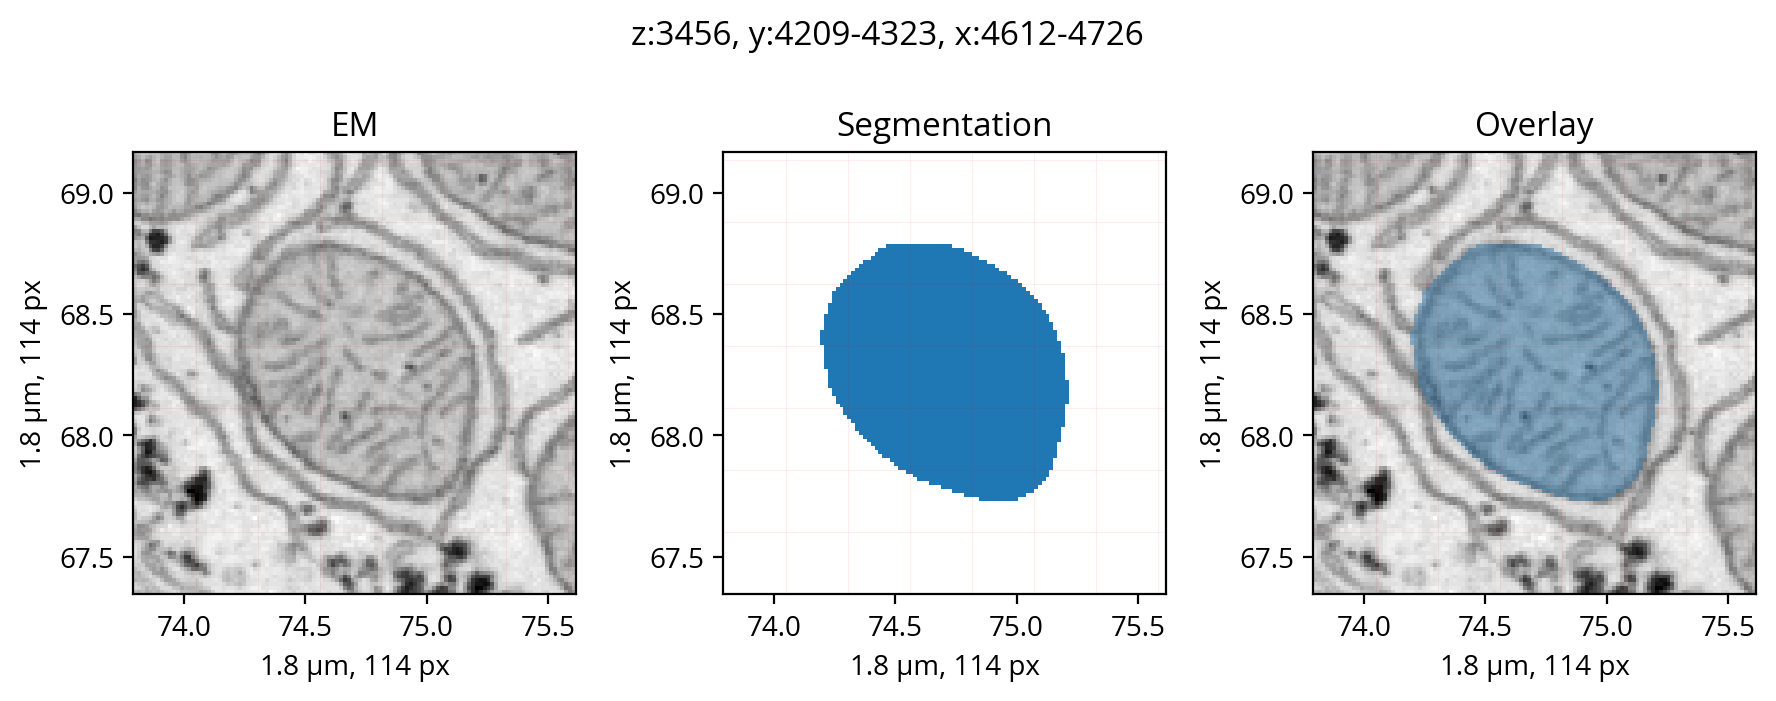

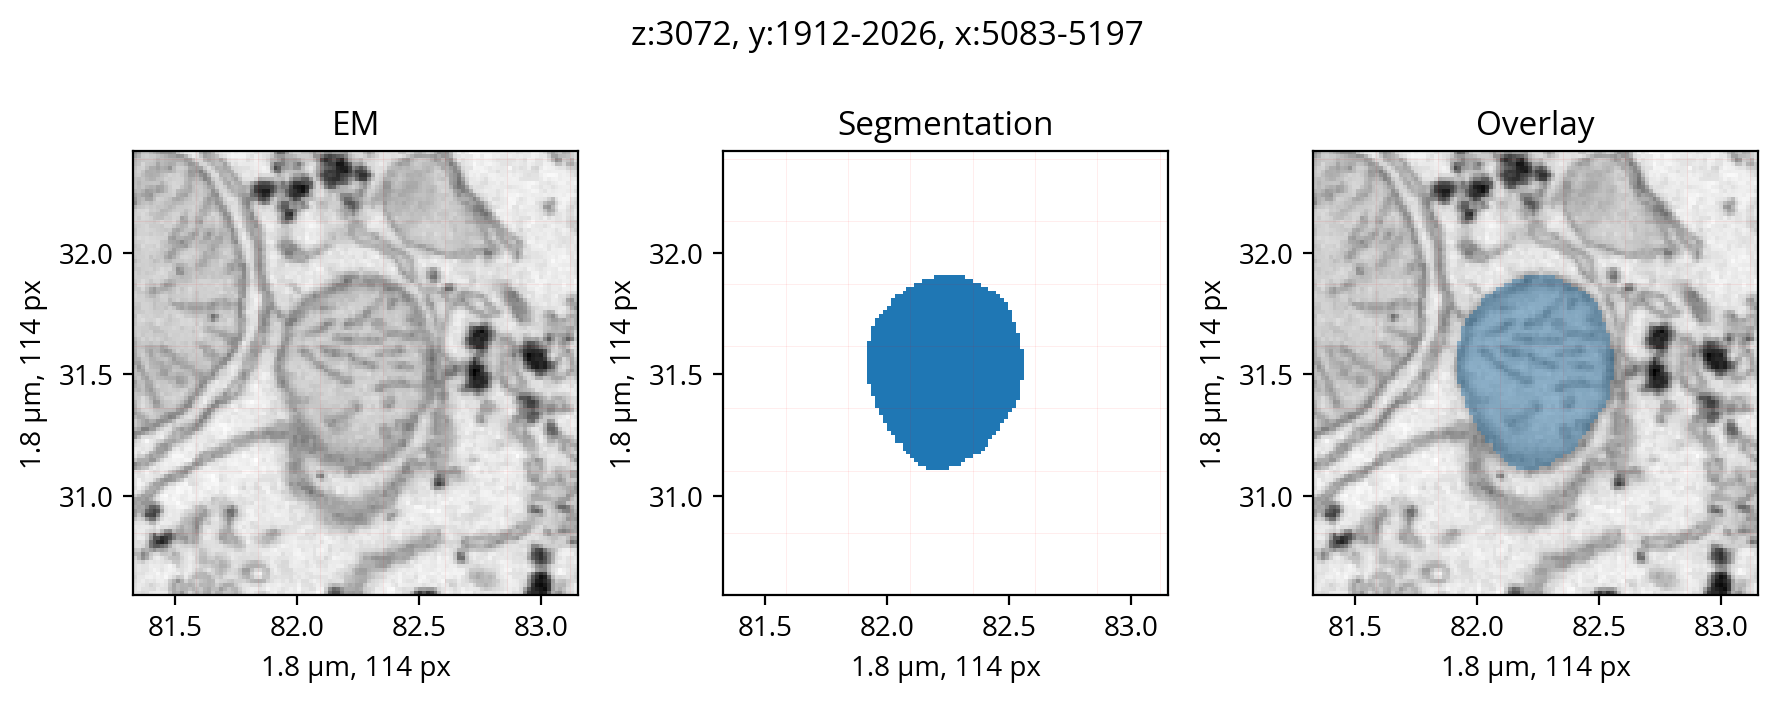

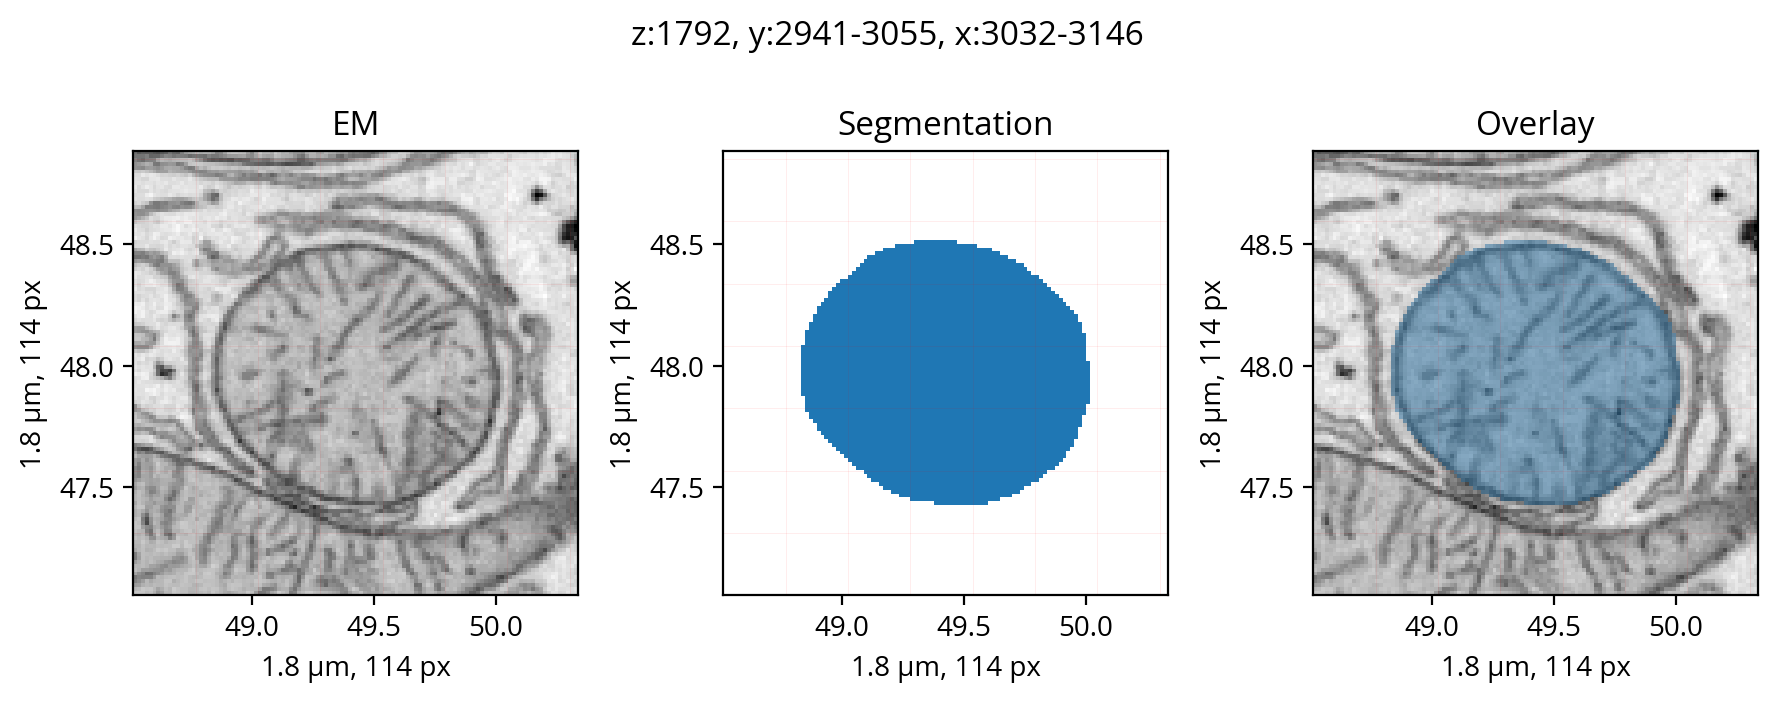

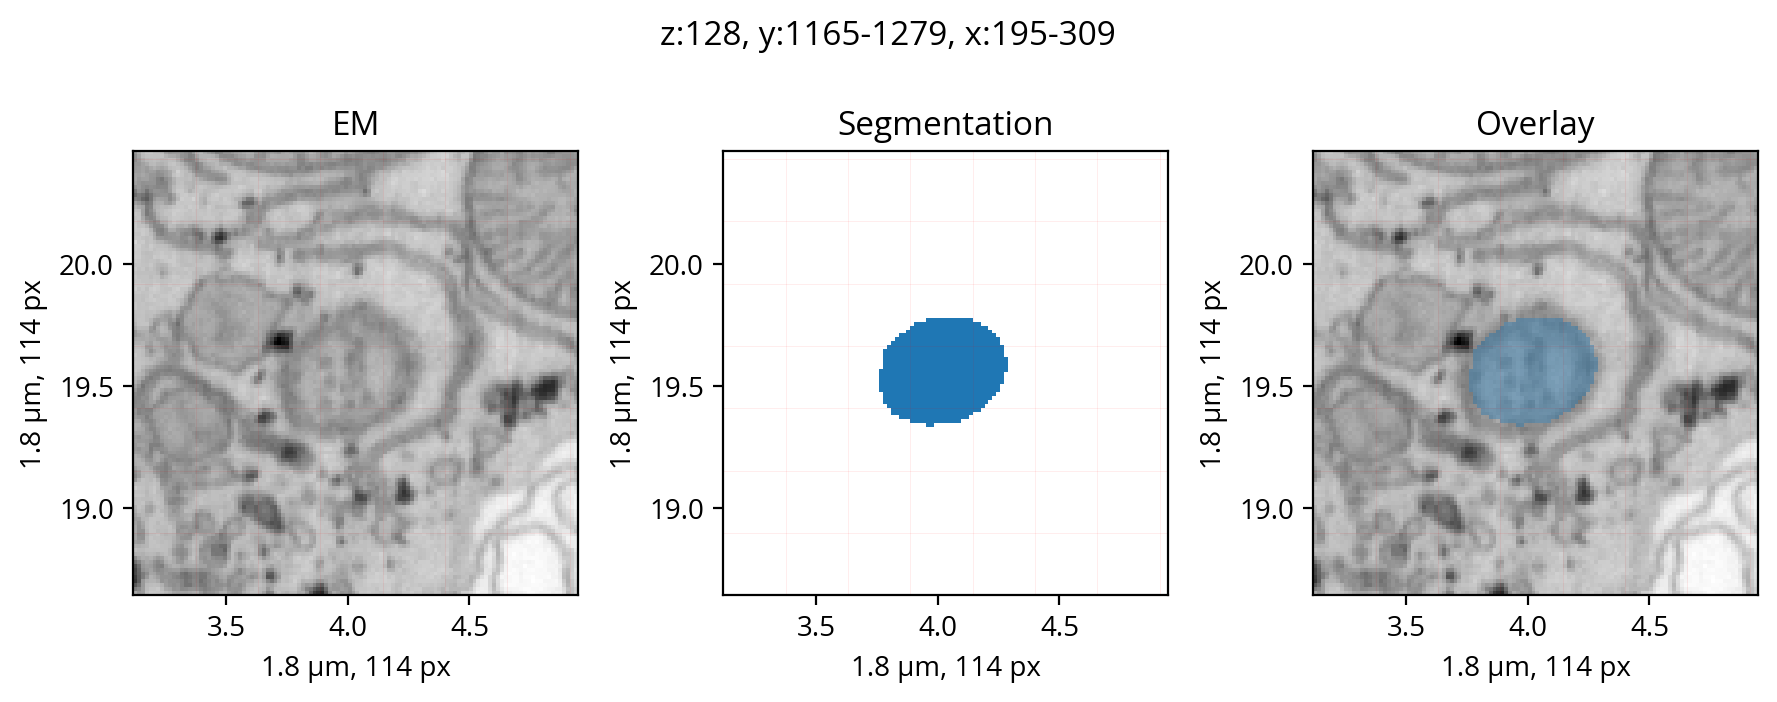

In [270]:
for far_id, _ in dists_to_ref_df.tail(5).iterrows():
    plot_representative_example(far_id)